# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** Mohammed Affan Khan  **Roll No.:** 1RUA25CSE0265  **Section:** G

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [2]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [3]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [7]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
print("Shape of the dataset:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of the dataset:
(150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  8

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [8]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

central_tendency = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mode": df[FEATURES].mode().iloc[0]
})

display(central_tendency)

workout_mode = df["preferred_workout"].mode()[0]

print("Mode of preferred_workout:", workout_mode)

,Mean,Median,Mode
workout_duration_minutes,54.618,54.35,57.8
monthly_membership_fee_inr,2283.067,2030.00,1440.0
attendance_percentage,84.210,85.10,85.1
weekly_visit_count,3.337,2.40,2.3


Mode of preferred_workout: Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**
The mean and median differ the most, in relative terms, for weekly_visit_count. The mean is 3.337, while the median is 2.40. Since the mean is noticeably higher than the median, it suggests that the distribution is likely right-skewed. This means that most members have a lower number of weekly visits, while a smaller number of members visit the gym much more frequently. Therefore, we would expect the tail of the distribution to stretch towards the higher values.

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [9]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
# Make a copy of the original dataframe
df_outlier = df.copy()

# Mean and median before adding the outlier
mean_before = df_outlier["monthly_membership_fee_inr"].mean()
median_before = df_outlier["monthly_membership_fee_inr"].median()

# Add the hypothetical ₹80,000 membership fee
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

# Mean and median after adding the outlier
mean_after = df_outlier["monthly_membership_fee_inr"].mean()
median_after = df_outlier["monthly_membership_fee_inr"].median()

print("Before adding ₹80,000:")
print("Mean:", mean_before)
print("Median:", median_before)

print("\nAfter adding ₹80,000:")
print("Mean:", mean_after)
print("Median:", median_after)

Before adding ₹80,000:
Mean: 2283.0666666666666
Median: 2030.0

After adding ₹80,000:
Mean: 2797.748344370861
Median: 2030.0


**Your answer:**
The mean changes much more because it uses every value in the dataset, so the very large ₹80,000 value pulls the mean upward. The median changes very little because it depends mainly on the middle value after the data is ordered, so one extreme value has much less effect on it.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [5]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
# Q5 — Manual calculation of variance and standard deviation

# Select the data
x = df["workout_duration_minutes"]

# Number of observations
n = len(x)

# Step 1: Calculate the mean
mean = sum(x) / n
print("Mean:", mean)

# Step 2: Calculate deviations from the mean
deviations = x - mean
print("\nDeviations:")
print(deviations)

# Step 3: Calculate squared deviations
squared_deviations = deviations ** 2
print("\nSquared deviations:")
print(squared_deviations)

# Step 4: Calculate sample variance
variance = sum(squared_deviations) / (n - 1)
print("\nSample variance:", variance)

# Step 5: Calculate standard deviation
standard_deviation = variance ** 0.5
print("Sample standard deviation:", standard_deviation)

# Verification using NumPy
print("\nVerification:")
print("np.var:", np.var(x, ddof=1))
print("np.std:", np.std(x, ddof=1))

Mean: 54.618

Deviations:
0      15.082
1      26.382
2       7.982
3      11.082
4      -5.318
        ...  
145     4.582
146    -1.818
147    11.482
148    25.482
149     8.582
Name: workout_duration_minutes, Length: 150, dtype: float64

Squared deviations:
0      227.467
1      696.010
2       63.712
3      122.811
4       28.281
        ...   
145     20.995
146      3.305
147    131.836
148    649.332
149     73.651
Name: workout_duration_minutes, Length: 150, dtype: float64

Sample variance: 129.89786174496643
Sample standard deviation: 11.397274312087362

Verification:
np.var: 129.89786174496643
np.std: 11.397274312087362


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

Monthly membership fee has the most outliers, with 2 values outside the IQR bounds. One realistic reason is that some members may have special membership plans, such as premium, annual, or one-time promotional memberships, which can make their fees much higher than the usual membership fees.

In [10]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
# Q6 — IQR and outlier detection

iqr_results = []

for feature in FEATURES:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[feature] < lower_bound) |
                (df[feature] > upper_bound)).sum()

    iqr_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outliers
    })

iqr_table = pd.DataFrame(iqr_results)

display(iqr_table)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
1,monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
2,attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
3,weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [11]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
# Q7 — Skewness and excess kurtosis

features = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

results = []

for feature in features:
    skewness = df[feature].skew()
    kurtosis = df[feature].kurt()

    # Classify based on skewness
    if skewness > 0.5:
        shape = "Right-skewed"
    elif skewness < -0.5:
        shape = "Left-skewed"
    else:
        shape = "Approximately symmetric"

    # Interpret excess kurtosis
    if kurtosis > 0:
        tails = "Heavier tails"
    elif kurtosis < 0:
        tails = "Lighter tails"
    else:
        tails = "Roughly normal tails"

    results.append({
        "Feature": feature,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis,
        "Shape": shape,
        "Tail Interpretation": tails
    })

q7_results = pd.DataFrame(results)

display(q7_results)

,Feature,Skewness,Excess Kurtosis,Shape,Tail Interpretation
0,workout_duration_minutes,0.081,-0.160,Approximately symmetric,Lighter tails
1,monthly_membership_fee_inr,1.177,1.863,Right-skewed,Heavier tails
2,attendance_percentage,-0.561,-0.324,Left-skewed,Lighter tails
3,weekly_visit_count,0.446,-1.375,Approximately symmetric,Lighter tails


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

I predict that weekly_visit_count may be bimodal because gym members can have very different workout habits. Some members may visit only a few times a week, while regular or highly active members may visit much more often, creating two possible groups.


## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

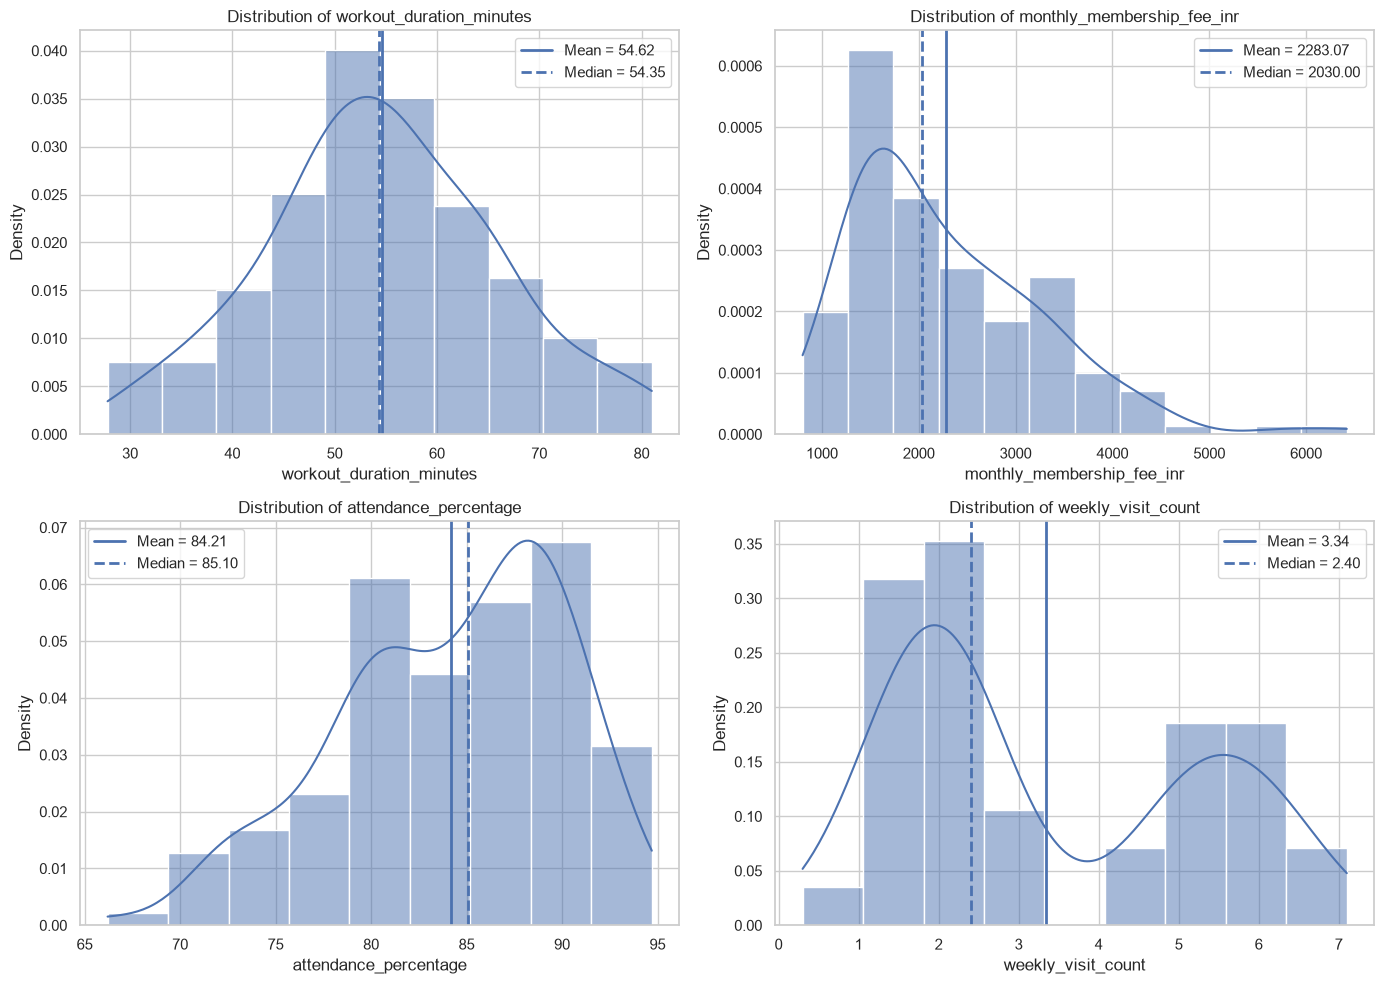

In [12]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
# Q9 — Histograms with KDE, mean and median

features = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, features):
    # Histogram with KDE
    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )

    # Calculate mean and median
    mean_value = df[feature].mean()
    median_value = df[feature].median()

    # Mean line
    ax.axvline(
        mean_value,
        linestyle="-",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )

    # Median line
    ax.axvline(
        median_value,
        linestyle="--",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )

    # Title and labels
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

    # Legend
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**
My prediction was confirmed. The histogram of weekly_visit_count shows two clear peaks, with one group of members visiting around 2 times per week and another group visiting around 5–6 times per week. The mean of 3.34 falls in the valley between the two groups, so it does not represent a typical number of visits for either group.

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

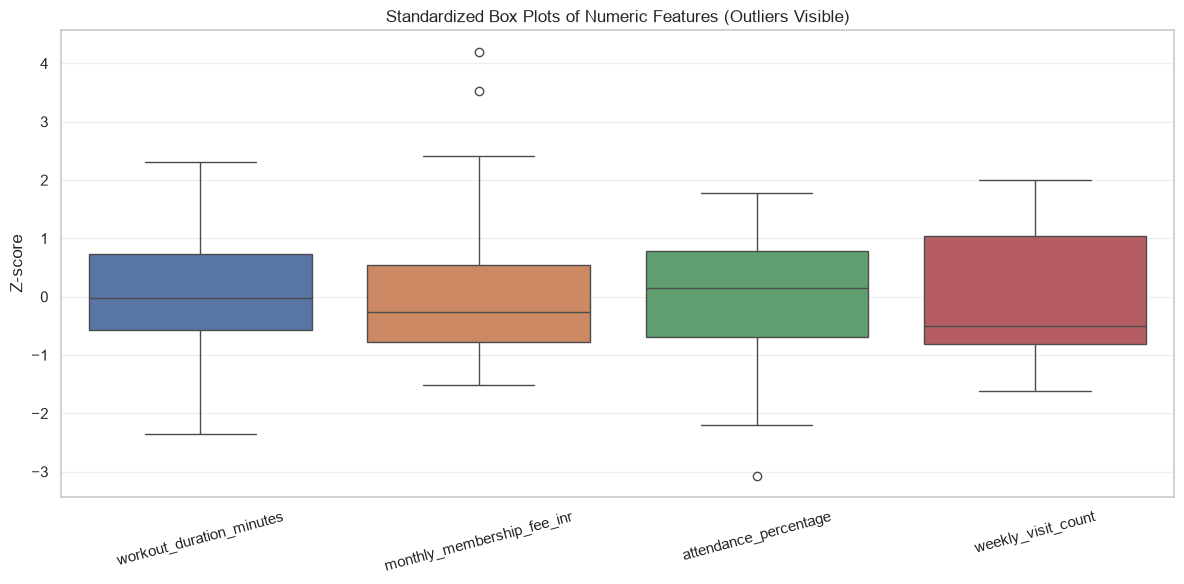

In [4]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
# Q11 — Standardize all four features and plot side-by-side box plots

features = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

# Standardize each feature using z-score
z_scores = pd.DataFrame()

for feature in features:
    mean = df[feature].mean()
    std = df[feature].std()
    z_scores[feature] = (df[feature] - mean) / std

# Plot box plots using Seaborn
plt.figure(figsize=(12, 6))

sns.boxplot(data=z_scores)

plt.title("Standardized Box Plots of Numeric Features (Outliers Visible)")
plt.ylabel("Z-score")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.
Pair 1 — weekly_visit_count and attendance_percentage: The scatter plot and the correlation value of 0.521 support my hypothesis that these two features have a relationship. It shows a moderate positive relationship, meaning members who visit the gym more often generally have higher attendance percentages.

Pair 2 — workout_duration_minutes and weekly_visit_count: The scatter plot and the correlation value of -0.011 support my hypothesis that these features have little to no relationship. The value is very close to zero, showing that the length of a workout does not have a meaningful linear relationship with how many times a member visits per week.


Correlation between weekly_visit_count and attendance_percentage: 0.521
Correlation between workout_duration_minutes and weekly_visit_count: -0.011


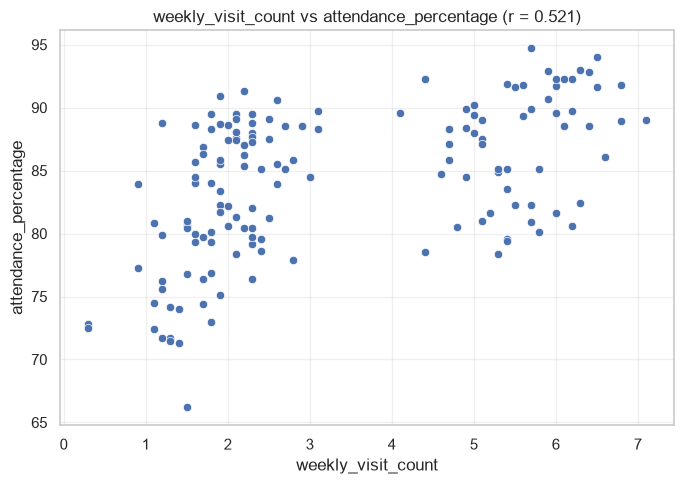

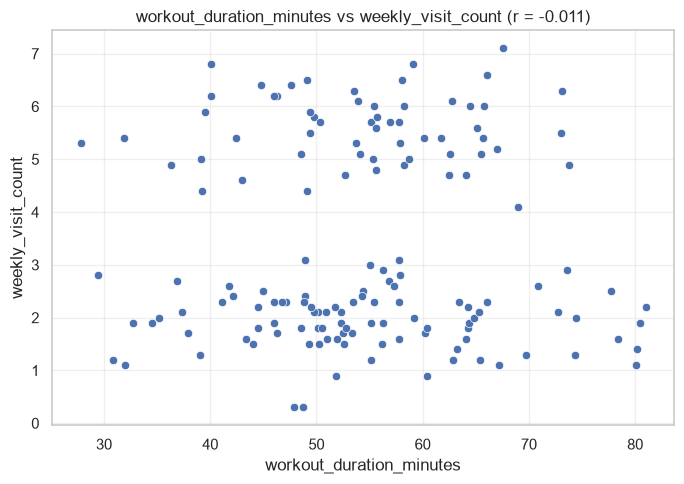

In [5]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
# Q12 — Scatter plots and Pearson correlations

# Pair 1: hypothesized relationship
x1 = "weekly_visit_count"
y1 = "attendance_percentage"

corr1 = df[x1].corr(df[y1])

# Pair 2: hypothesized little/no relationship
x2 = "workout_duration_minutes"
y2 = "weekly_visit_count"

corr2 = df[x2].corr(df[y2])

# Print correlation values
print(f"Correlation between {x1} and {y1}: {corr1:.3f}")
print(f"Correlation between {x2} and {y2}: {corr2:.3f}")

# Scatter plot 1 using Seaborn
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x=x1,
    y=y1
)

plt.xlabel(x1)
plt.ylabel(y1)
plt.title(f"{x1} vs {y1} (r = {corr1:.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot 2 using Seaborn
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x=x2,
    y=y2
)

plt.xlabel(x2)
plt.ylabel(y2)
plt.title(f"{x2} vs {y2} (r = {corr2:.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [15]:
# TODO: Q13 — assemble the comparative summary table
# Q13 — Summary table

features = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

summary_table = pd.DataFrame({
    "Mean": [df[f].mean() for f in features],
    "Median": [df[f].median() for f in features],
    "Standard Deviation": [df[f].std() for f in features],
    "IQR": [df[f].quantile(0.75) - df[f].quantile(0.25) for f in features],
    "Skewness": [df[f].skew() for f in features],
    "Excess Kurtosis": [df[f].kurt() for f in features]
}, index=features)

display(summary_table)

,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.081,-0.160
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.177,1.863
attendance_percentage,84.210,85.10,5.874,8.600,-0.561,-0.324
weekly_visit_count,3.337,2.40,1.886,3.500,0.446,-1.375


**Your answer (recommendation paragraph):**
For workout_duration_minutes, I would report the mean and standard deviation because the mean (54.62) and median (54.35) are very close, and the skewness (0.081) is close to zero, showing that the distribution is fairly symmetric. For monthly_membership_fee_inr, I would report the median and IQR because the mean (2283.07) is higher than the median (2030), while the skewness (1.177) shows a clear right-skew, with some high fees affecting the average. For attendance_percentage, I would use the median and IQR because the median (85.10) is higher than the mean (84.21) and the skewness (-0.561) indicates some left-skew. For weekly_visit_count, I would also use the median and IQR because the mean (3.34) is much higher than the median (2.40), and its histogram shows two distinct groups of members.

---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [16]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories
# Group by preferred workout and compare mean attendance percentage

attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .mean()
      .reset_index()
)

attendance_by_workout.columns = [
    "Preferred Workout",
    "Mean Attendance Percentage"
]

display(attendance_by_workout)

,Preferred Workout,Mean Attendance Percentage
0,Cardio,83.558
1,CrossFit,82.325
2,Weights,85.526
3,Yoga,84.029


The mean attendance percentage is different across the four workout categories, but the difference is not very large. Weights has the highest average attendance, while CrossFit has the lowest. This could be because members who prefer weights may follow a more regular workout routine, while attendance can also depend on personal schedules and commitment levels.

---

### Before you submit
- [x] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [x] Every `# TODO` cell has working code, not just comments
- [x] Every "Your answer" cell has a written response in your own words
- [x] Did not modify the Part 1 dataset-generation code or the random seed